# Part 2.2

her har systemet en overflow-struktur. Det betyr at vannet ikke går direkte til målepunktet, men at det må samle seg opp til et visst nivå før det begynner å renne over i den delen av systemet hvor målingen gjøres.

Dette gir ikke-lineær oppførsel, som skiller seg fra det enkle lineære reservoarmodellen i 2.1.

In [ ]:
# Set working directory
setwd("")
getwd()

# Load package
library(e1071)
library(ctsmTMB)
library(dplyr)
library(lubridate)
library(readr)
library(ggplot2)
library(data.table)
library(ggplot2)
library(patchwork)

###       PART 2       ###

data <- read.csv("ex2_overflow.csv", header = TRUE, sep = ",", stringsAsFactors = FALSE)


# build the data frame the model expects
data <- data %>%
  mutate(
    time = as.POSIXct(timestamp, format = "%Y-%m-%d %H:%M:%S", tz = "UTC"),
    t = as.numeric(difftime(time, min(time), units = "hour"))
  ) %>%
  arrange(t) %>%
  select(t, rainfall, stormwater)

#data$t <- data$t/60

tail(data)


[1] "C:/Users/jhaeg/OneDrive/Documents/MSc_MMC/3_semester/Advanced_Time_Series_Analysis/Assigments/3/Data"

Warning message:
"package 'ctsmTMB' was built under R version 4.5.2"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union


Warning message:
"package 'readr' was built under R version 4.5.2"

Attaching package: 'ggplot2'


The following object is masked from 'package:e1071':

    element



Attaching package: 'data.table'


The following objects are masked from 'package:lubridate':

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from 'package:dplyr':

    between, first, last


Warning message:
"package 'patchwork' was built under R version 4.5.2"


,t,rainfall,stormwater
,<dbl>,<dbl>,<dbl>
596,9.916667,0,9.068
597,9.933333,0,9.071
598,9.950000,0,9.076
599,9.966667,0,9.059
600,9.983333,0,9.026
601,10.000000,0,9.038


## 2.2.1

In [2]:
model <- ctsmTMB$new()

# Differential Equation
n = 3

model$addSystem(
  dx1 ~ A * rainfall * dt - (3/K) * x1 * dt + sigma_x * dw1,
  dx2 ~ (3/K) * x1 * dt - (3/K) * x2 * dt + sigma_x * dw2,
  dx3 ~ (3/K) * x2 * dt - (3/K) * x3 * dt + sigma_x * dw3,
  dx4 ~ (3/K) * x3 * dt + sigma_x * dw4
)

#Parameters and estimation
model$addObs(stormwater ~ x4)
model$setVariance(stormwater ~ sigma_y^2)
model$addInput(rainfall)

model$setParameter(
  A       = c(initial = 1,  lower = 1e-6, upper = 1e3),
  K       = c(initial = 10, lower = 1e-6, upper = 1e4),
  sigma_x = c(initial = 0.1, lower = 1e-8, upper = 10),
  sigma_y = c(initial = 0.1, lower = 1e-8, upper = 10)
)
model$setInitialState(list(c(0, 0, 0, 0), diag(c(0.1, 0.1, 0.1, 0.1)) ))

# now estimate
fit <- model$estimate(data)

summary(fit)
print(fit)

A       <- coef(fit)["A"]
K       <- coef(fit)["K"]
sigma_x <- coef(fit)["sigma_x"]
sigma_y <- coef(fit)["sigma_y"]


Checking model components...

Checking and setting data...

Constructing objective function and derivative tables...

Minimizing the negative log-likelihood...



  0:     738.95631:  1.00000  10.0000 0.100000 0.100000
 10:    -1332.9025: 0.181441  1.74833 0.194441 1.00000e-08
 20:    -1382.1919: 0.396826  1.66617 0.180730 1.00000e-08
 30:    -1429.5156: 0.618252  1.56111 0.168434 1.00000e-08
 40:    -1465.2431: 0.843847  1.43867 0.159890 1.00000e-08
 50:    -1476.2943:  1.04166  1.43655 0.158863 1.00000e-08


	 Optimization finished!:
            Elapsed time: 0.13 seconds.
            The objective value is: -1.476773e+03
            The maximum gradient component is: 4e-03
            The convergence message is: relative convergence (4)
            Iterations: 56
            Evaluations: Fun: 64 Grad: 57
            See stats::nlminb for available tolerance/control arguments.

Returning results...

Finished!



Coefficent Matrix 
          Estimate Std. Error t value Pr(>|t|)    
A       1.08704738 0.05662274  19.198   <2e-16 ***
K       1.42968493 0.05759367  24.824   <2e-16 ***
sigma_x 0.15991363 0.00461944  34.617   <2e-16 ***
sigma_y 0.00000001 0.00158470   0.000        1    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Coefficent Matrix 
          Estimate Std. Error t value Pr(>|t|)    
A       1.08704738 0.05662274  19.198   <2e-16 ***
K       1.42968493 0.05759367  24.824   <2e-16 ***
sigma_x 0.15991363 0.00461944  34.617   <2e-16 ***
sigma_y 0.00000001 0.00158470   0.000        1    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Plot of the linear model

Number of reservoirs (n): 3 
Number of states: 4 


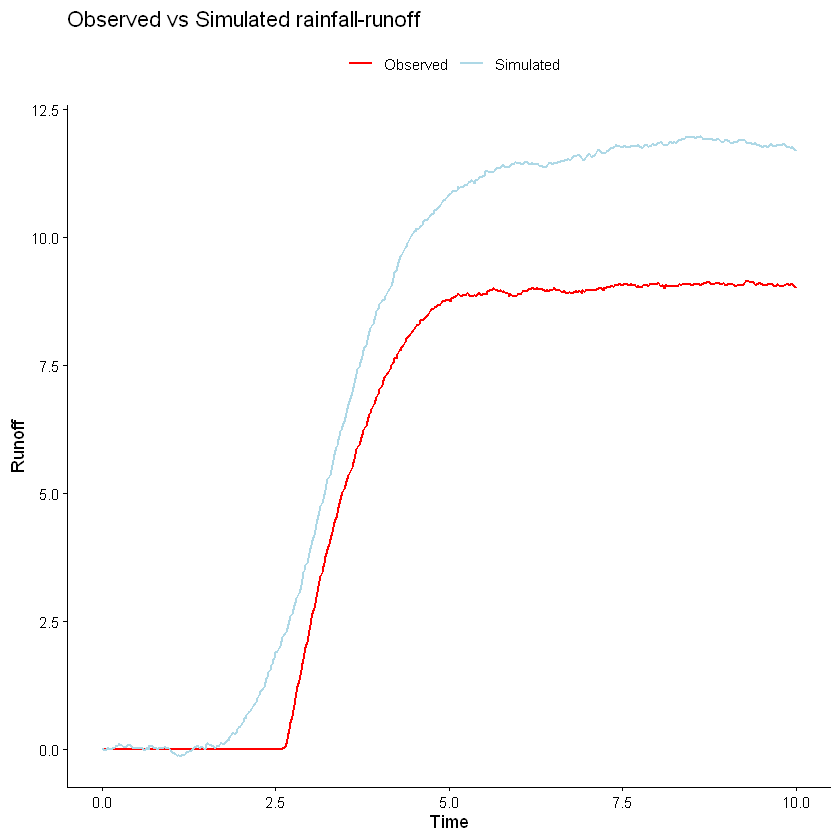

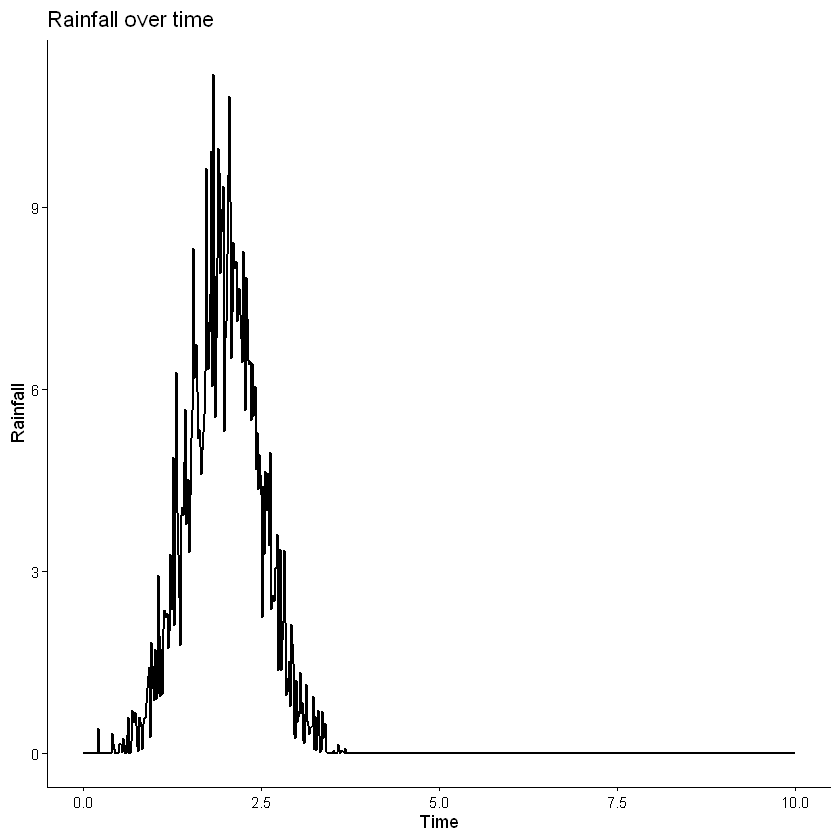

In [3]:
# ---- Choose n (same n as in your ctsmTMB model) ----
n <- 3                 # e.g. 1, 2, 3, ..., 6
n_states <- n + 1      # x1, x2, ..., x_{n+1}

cat("Number of reservoirs (n):", n, "\n")
cat("Number of states:", n_states, "\n")

# ---- Coefficients from fit (or take from coef(fit)) ----
A <- 1.0870
K <- 1.4297
sigma_x <- 0.1599
sigma_y <- 0.0000001

# Time handling 
time <- if ("t" %in% names(data)) data$t else data$time
time_num <- as.numeric(time)
n_t <- length(time_num)

rain <- data$rainfall
rain[!is.finite(rain)] <- 0

# State matrix: rows = time, cols = x1..x_{n+1} 
X <- matrix(0, nrow = n_t, ncol = n_states)
colnames(X) <- paste0("x", 1:n_states)

set.seed(123)

# Euler–Maruyama simulation matching your SDE structure 
for (i in 2:n_t) {
  dt_i <- time_num[i] - time_num[i - 1]
  stopifnot(is.finite(dt_i) && dt_i > 0)

  # Brownian increments for each state
  dw <- rnorm(n_states, mean = 0, sd = sqrt(dt_i))

  # previous state
  x_prev <- X[i - 1, ]

  # 1) First reservoir:
  
  X[i, 1] <- x_prev[1] +
    (A * rain[i] - (n / K) * x_prev[1]) * dt_i +
    sigma_x * dw[1]

  # 2) Middle reservoirs (if any)
  if (n_states > 2) {
    for (k in 2:(n_states - 1)) {
      # dx_k = (n/K)*x_{k-1} - (n/K)*x_k + noise
      X[i, k] <- x_prev[k] +
        ((n / K) * x_prev[k - 1] - (n / K) * x_prev[k]) * dt_i +
        sigma_x * dw[k]
    }
  }

  # 3) Last reservoir:
  X[i, n_states] <- x_prev[n_states] +
    ( (n / K) * x_prev[n_states - 1] ) * dt_i +
    sigma_x * dw[n_states]
}

# Runoff / stormwater = last state x_{n+1} 
stormwater_sim <- X[, n_states]


df_plot <- data.frame(
  time      = time,
  observed  = data$stormwater,
  simulated = stormwater_sim,
  rainfall  = data$rainfall
)



ggplot(df_plot, aes(x = time)) +
  geom_line(aes(y = observed,  color = "Observed"), linewidth = 0.7) +
  geom_line(aes(y = simulated, color = "Simulated"), linewidth = 0.7) +
  scale_color_manual(values = c("Observed" = "red",
                                "Simulated" = "lightblue")) +
  labs(
    title = "Observed vs Simulated rainfall-runoff",
    y = "Runoff",
    x = "Time",
    color = ""          # Legend title
  ) +
  theme_classic() +
  theme(
    plot.title = element_text(size = 13),
    legend.position = "top"   # move legend above plot (assignment style)
  )


## ---- Plot 2: Rainfall ----
ggplot(df_plot, aes(x = time, y = rainfall)) +
  geom_line(linewidth = 0.7, color = "black") +
  labs(
    title = "Rainfall over time",
    y = "Rainfall",
    x = "Time"
  ) +
  theme_classic() +
  theme(
    plot.title = element_text(size = 13)
  )



### 2.2.2

In [4]:
model <- ctsmTMB$new()

n <- 3

model$addSystem(
  dx1 ~ A * rainfall * dt - (3 / K) * x1 * dt + sigma_x * dw1,
  dx2 ~ (3 / K) * x1 * dt - (3 / K) * x2 * dt + sigma_x * dw2,
  dx3 ~ (3 / K) * x2 * dt - (3 / K) * x3 * dt + sigma_x * dw3,
  dx4 ~ (3 / K) * x3 * (1 / (1 + exp(-alpha * (x3 - beta)))) * dt + sigma_x * dw4
)

model$addObs(stormwater ~ x4)
model$setVariance(stormwater ~ sigma_y^2)
model$addInput(rainfall)

model$setParameter(
  A       = c(initial = 0.9,  lower = 1e-6, upper = 10),
  K       = c(initial = 1.3,  lower = 1e-3, upper = 20),
  sigma_x = c(initial = 0.15, lower = 1e-4, upper = 5),
  sigma_y = c(initial = 0.01, lower = 1e-4, upper = 5),
  alpha   = c(initial = 5,    lower = 0.1,  upper = 10),
  beta    = c(initial = 2,    lower = 0.5,  upper = 6)
)

model$setInitialState(list(c(0, 0, 0, 0), diag(c(0.1, 0.1, 0.1, 0.1))))

fit_222 <- model$estimate(data)
summary(fit_222)


Checking model components...

Checking and setting data...

Constructing objective function and derivative tables...

Minimizing the negative log-likelihood...



  0:    -1415.9644: 0.900000  1.30000 0.150000 0.0100000  5.00000  2.00000
 10:    -1499.6736:  1.03477  1.44937 0.157797 0.000100000  5.00064  1.93633
 20:    -1517.5948:  1.18539  1.56679 0.151086 0.000100000  4.96516  2.01544
 30:    -1520.8351:  1.23164  1.60382 0.150024 0.000100000  4.94636  2.04312
 40:    -1521.8292:  1.24566  1.62164 0.149137 0.000146776  4.93713  2.05499
 50:    -1522.3818:  1.25659  1.62988 0.148698 0.000100000  4.93546  2.05393
 60:    -1522.8588:  1.26851  1.63838 0.148581 0.000205910  4.93245  2.05621
 70:    -1523.2450:  1.27989  1.64740 0.148403 0.000100000  4.92699  2.06462
 80:    -1523.5446:  1.28925  1.65707 0.148284 0.000100000  4.91932  2.07678
 90:    -1523.7748:  1.29675  1.66657 0.148182 0.000100000  4.91038  2.09064
100:    -1523.9566:  1.30293  1.67568 0.148097 0.000100000  4.90046  2.10542
110:    -1524.1037:  1.30799  1.68439 0.148024 0.000100000  4.88973  2.12070
120:    -1524.2256:  1.31208  1.69279 0.147962 0.000100000  4.87837  2.13628
1

	 Optimization finished!:
            Elapsed time: 0.63 seconds.
            The objective value is: -1.526421e+03
            The maximum gradient component is: 3e-04
            The convergence message is: relative convergence (4)
            Iterations: 302
            Evaluations: Fun: 328 Grad: 303
            See stats::nlminb for available tolerance/control arguments.

Returning results...

Finished!



Coefficent Matrix 
         Estimate Std. Error t value  Pr(>|t|)    
A       1.4331141  0.0872416 16.4270 < 2.2e-16 ***
K       1.6701008  0.0656463 25.4409 < 2.2e-16 ***
sigma_x 0.1465887  0.0066469 22.0539 < 2.2e-16 ***
sigma_y 0.0012730  0.0048926  0.2602 0.7948112    
alpha   2.8551971  0.7603658  3.7550 0.0001902 ***
beta    2.2091978  0.2077496 10.6339 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


[1] 1.433114090 1.670100827 0.146588687 0.001272987 2.855197092 2.209197778


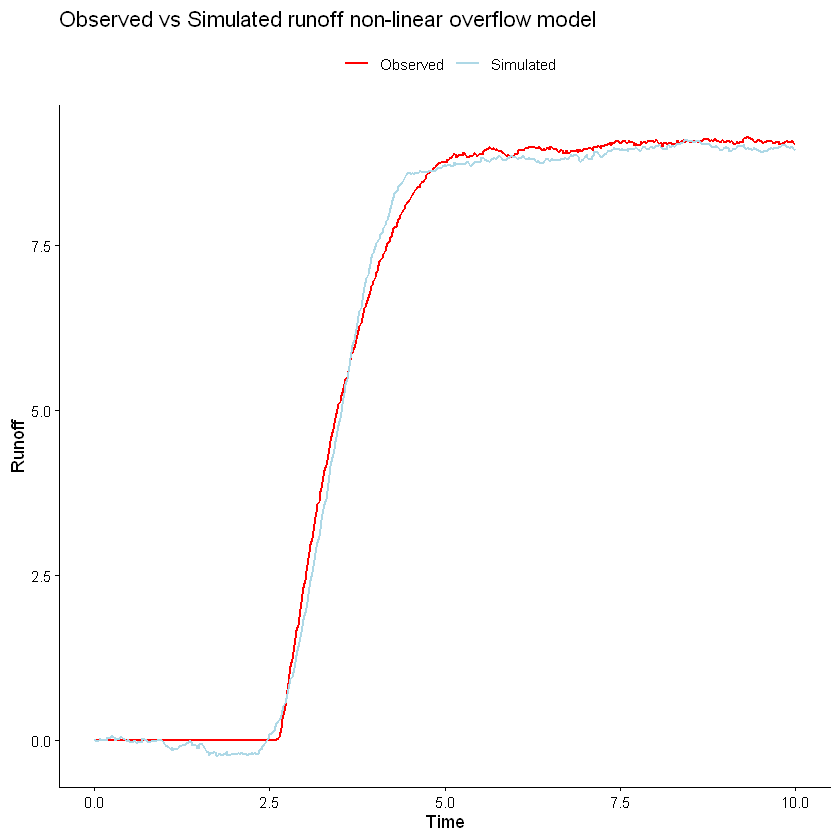

In [5]:
library(ggplot2)

# ---- Parameters from the non-linear fit (2.2.2) ----
par_hat <- model$getParameters(type = "all", value = "estimate")
print(par_hat)

A       <- 1.433
K       <- 1.670
sigma_x <- 0.147
sigma_y <- 0.001
alpha   <- 2.855
beta    <- 2.209

# ---- Time and input ----
time     <- data$t
time_num <- as.numeric(time)
n_t      <- length(time_num)

rain <- data$rainfall
rain[!is.finite(rain)] <- 0

n        <- 3
n_states <- n + 1

X <- matrix(0, nrow = n_t, ncol = n_states)
colnames(X) <- paste0("x", 1:n_states)

set.seed(123)

for (i in 2:n_t) {
  dt_i <- time_num[i] - time_num[i - 1]
  stopifnot(is.finite(dt_i) && dt_i > 0)

  dw     <- rnorm(n_states, 0, sqrt(dt_i))
  x_prev <- X[i - 1, ]

  # linear part:
  X[i, 1] <- x_prev[1] +
    (A * rain[i] - (n / K) * x_prev[1]) * dt_i + sigma_x * dw[1]

  X[i, 2] <- x_prev[2] +
    ((n / K) * x_prev[1] - (n / K) * x_prev[2]) * dt_i + sigma_x * dw[2]

  X[i, 3] <- x_prev[3] +
    ((n / K) * x_prev[2] - (n / K) * x_prev[3]) * dt_i + sigma_x * dw[3]

  # non-linear overflow into x4:
  q <- 1 / (1 + exp(-alpha * (x_prev[3] - beta)))
  X[i, 4] <- x_prev[4] +
    ((n / K) * x_prev[3] * q) * dt_i + sigma_x * dw[4]
}

stormwater_sim <- X[, 4]

df_plot <- data.frame(
  time      = time,
  observed  = data$stormwater,
  simulated = stormwater_sim,
  rainfall  = data$rainfall
)

# ---- Plot 1: Observed vs simulated (2.2.2) ----
ggplot(df_plot, aes(x = time)) +
  geom_line(aes(y = observed,  color = "Observed"), linewidth = 0.7) +
  geom_line(aes(y = simulated, color = "Simulated"), linewidth = 0.7) +
  scale_color_manual(values = c("Observed" = "red",
                                "Simulated" = "lightblue")) +
  labs(
    title = "Observed vs Simulated runoff non-linear overflow model",
    y = "Runoff",
    x = "Time",
    color = ""
  ) +
  theme_classic() +
  theme(
    legend.position = "top",
    plot.title = element_text(size = 13)
  )



## 2.2.3

In [6]:
# Assuming you already have: fit <- model$estimate(data)

f <- fit_222

cov_mat <- f$cov.fixed

cor_mat <- cov2cor(cov_mat)

round(cor_mat, 3)



,A,K,sigma_x,sigma_y,alpha,beta
A,1.000,-0.028,0.001,0.000,-0.658,0.634
K,-0.028,1.000,-0.002,0.003,0.346,0.435
sigma_x,0.001,-0.002,1.000,-0.766,-0.005,-0.006
sigma_y,0.000,0.003,-0.766,1.000,0.006,0.010
alpha,-0.658,0.346,-0.005,0.006,1.000,-0.251
beta,0.634,0.435,-0.006,0.010,-0.251,1.000


## 2.2.4

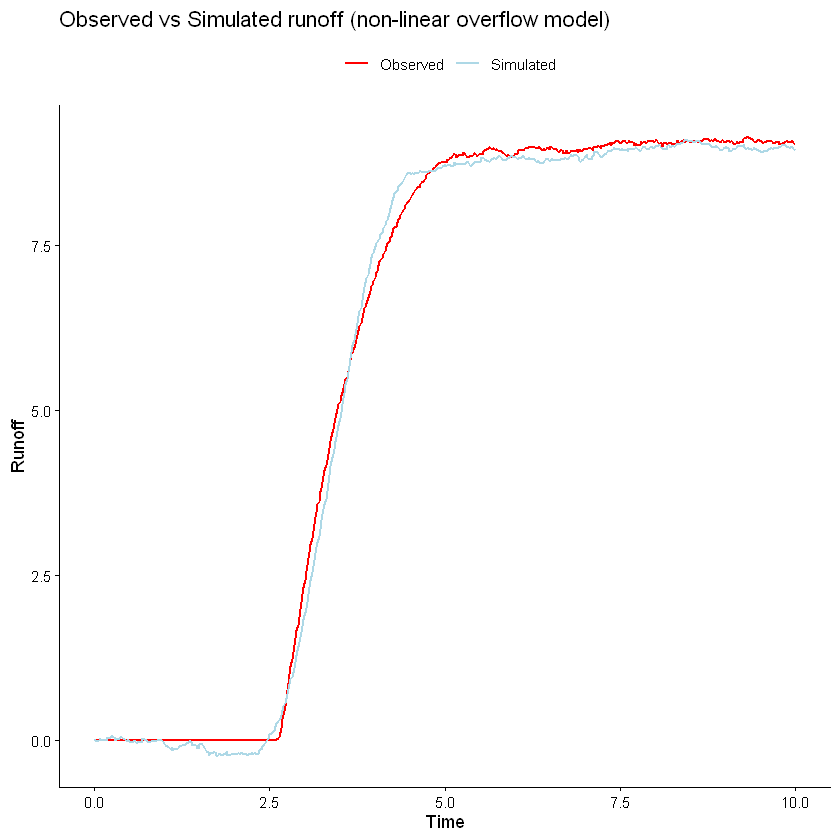

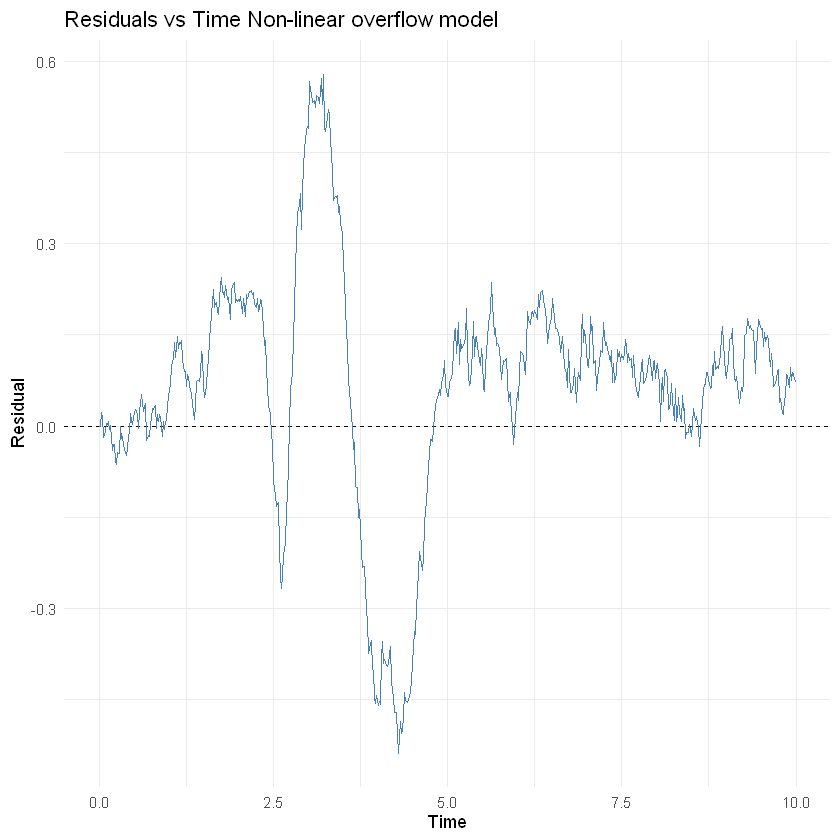

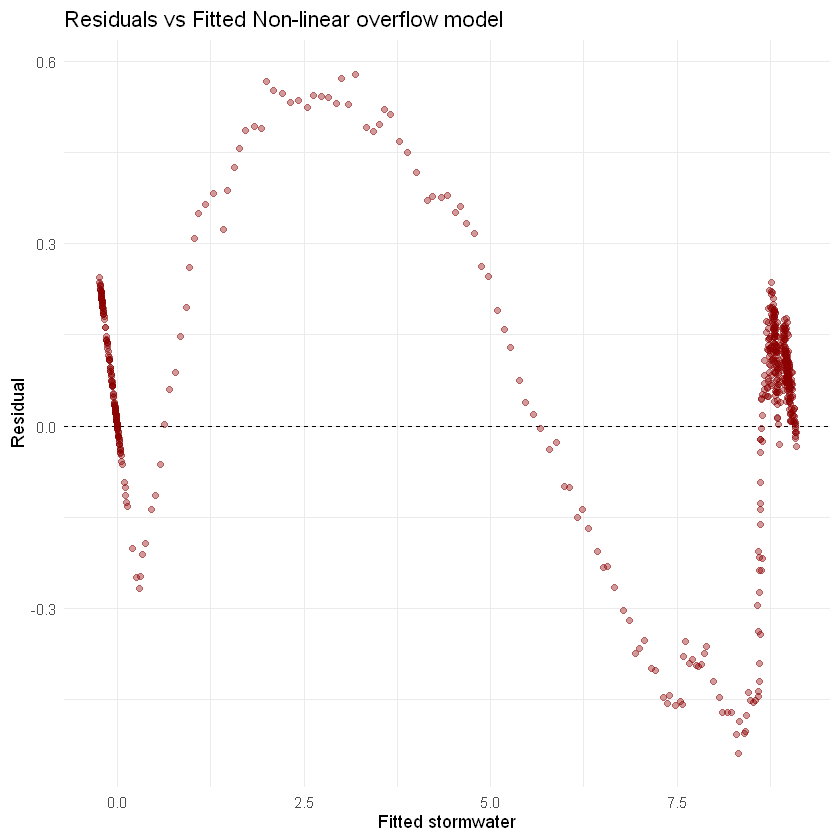

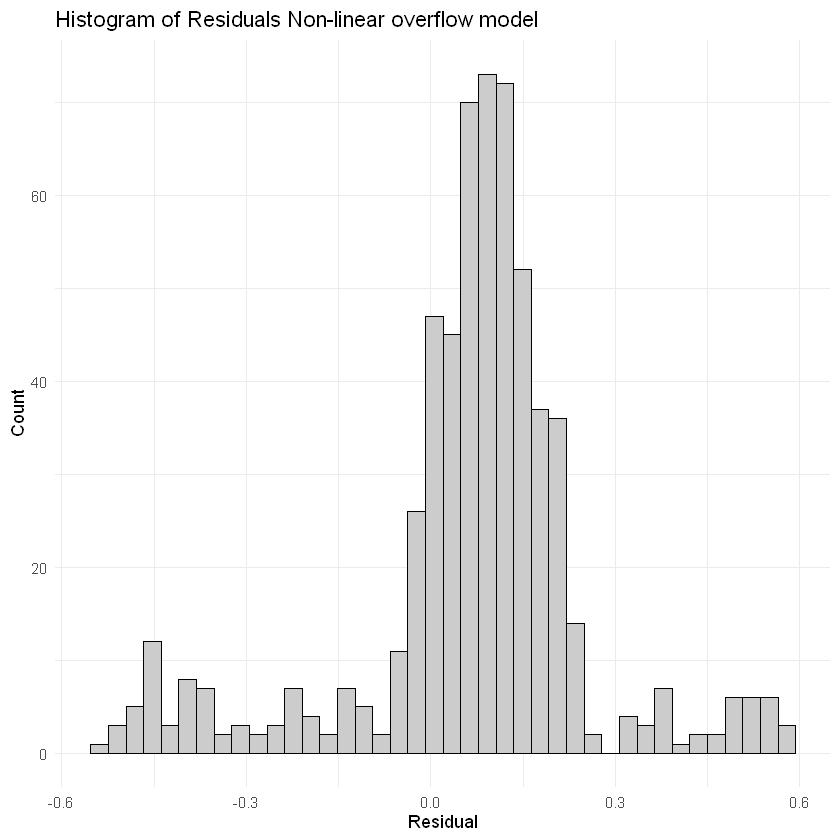

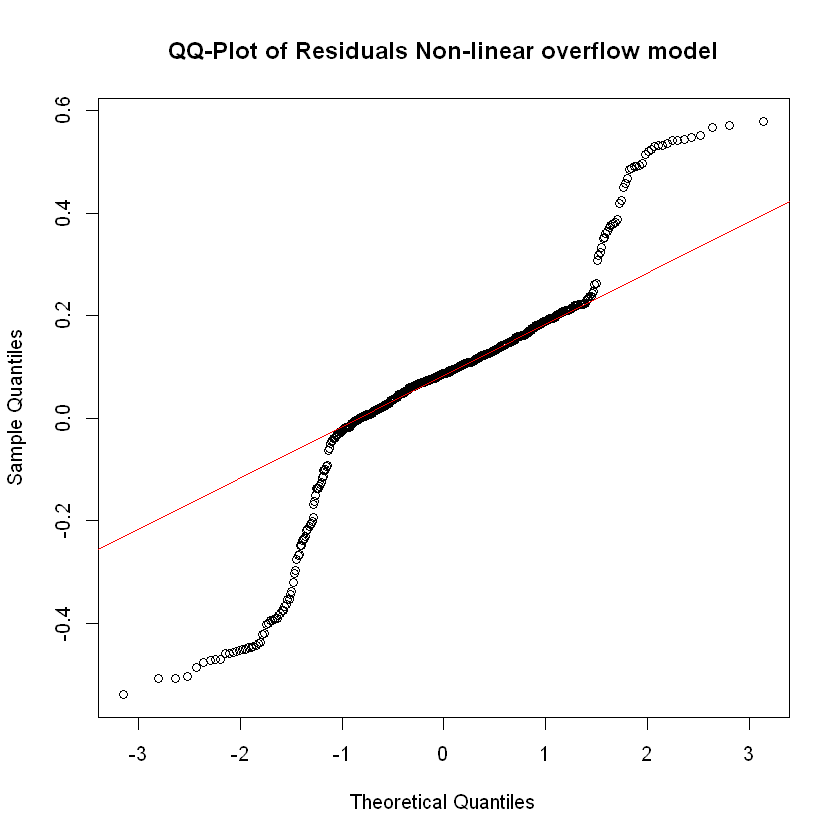

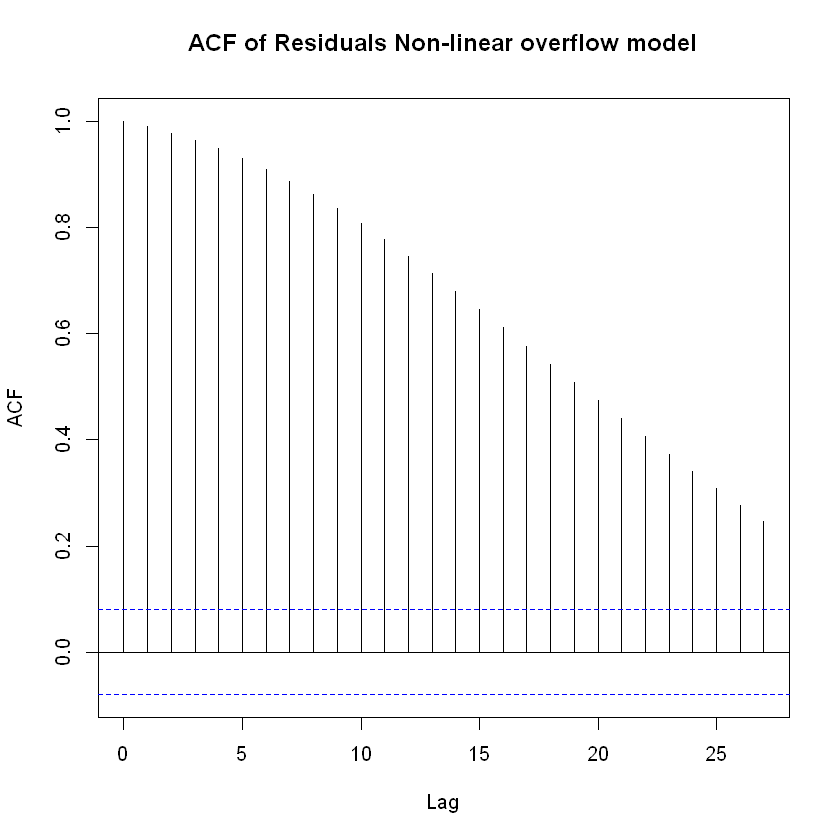

In [8]:

ggplot(df_plot, aes(x = time)) +
  geom_line(aes(y = observed,  color = "Observed"), linewidth = 0.7) +
  geom_line(aes(y = simulated, color = "Simulated"), linewidth = 0.7) +
  scale_color_manual(values = c("Observed" = "red",
                                "Simulated" = "lightblue")) +
  labs(
    title = "Observed vs Simulated runoff (non-linear overflow model)",
    y = "Runoff",
    x = "Time",
    color = ""
  ) +
  theme_classic() +
  theme(
    legend.position = "top",
    plot.title = element_text(size = 13)
  )

# ============================================================
# =============== Residual Analysis for 2.2.2 =================
# ============================================================

# 1) Compute residuals
df_plot$residual <- df_plot$observed - df_plot$simulated

# 2) Residuals vs Time
ggplot(df_plot, aes(x = time, y = residual)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_line(color = "steelblue") +
  labs(
    title = "Residuals vs Time Non-linear overflow model",
    x = "Time", y = "Residual"
  ) +
  theme_minimal()

# 3) Residuals vs Fitted
ggplot(df_plot, aes(x = simulated, y = residual)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_point(alpha = 0.4, color = "darkred") +
  labs(
    title = "Residuals vs Fitted Non-linear overflow model",
    x = "Fitted stormwater", y = "Residual"
  ) +
  theme_minimal()

# 4) Histogram of residuals
ggplot(df_plot, aes(x = residual)) +
  geom_histogram(bins = 40, colour = "black", fill = "grey80") +
  labs(
    title = "Histogram of Residuals Non-linear overflow model",
    x = "Residual", y = "Count"
  ) +
  theme_minimal()

# 5) QQ-Plot
qqnorm(df_plot$residual,
       main = "QQ-Plot of Residuals Non-linear overflow model")
qqline(df_plot$residual, col = "red")

# 6) Autocorrelation function (ACF)
acf(df_plot$residual,
    main = "ACF of Residuals Non-linear overflow model")
